In [39]:
import math
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


### AT: Temperature
### V: Vacuum
### AP: Pressure
### RH: Humidity

## PE: Produced Energy

In [4]:
df.isnull().any()

AT    False
V     False
AP    False
RH    False
PE    False
dtype: bool

In [5]:
df.shape

(9568, 5)

In [6]:
X = df.drop(columns=["PE"],axis=1)
Y = df["PE"]

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
)

### Scaling

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Converting data to Tensors

In [9]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled,dtype=torch.float32) # Conversion to a tensor
Y_train_tensor = torch.tensor(Y_train.values,dtype=torch.float32).view(-1,1) # Conversion to a n x 1 array

X_test_tensor = torch.tensor(X_test_scaled,dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test.values,dtype=torch.float32).view(-1,1)


### Conversion of data to tensor datasets for training and testing

In [10]:
from torch.utils.data import TensorDataset,DataLoader

train_dataset = TensorDataset(
    X_train_tensor,
    Y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    Y_test_tensor
)

In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)

### Deep Learning

In [23]:
# Definition of Model

class ANN(nn.Module):
    
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
            # 1st Hidden Layer
            nn.Linear(
                in_features=X_train.shape[1],
                out_features=6
            ),
            nn.ReLU(),

            # 2nd Hidden Layer
            nn.Linear(
                in_features=6,
                out_features=6
            ),
            nn.ReLU(),

            # Output Layer
            nn.Linear(
                in_features=6,
                out_features=1
            )
        )

    def forward(self,x):
        return self.model(x) 

In [24]:
import torch.optim as optim
model = ANN()

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters())

In [ ]:
epochs = 100

training_losses = []
val_losses = []

best_val_loss = float("inf")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # Total training loss for 1 epoch
    for xb,yb in train_loader:
        ## xb: Features of 1 batch
        ## yb : Labels of 1 batch

        optimizer.zero_grad() # Reset gradients for this batch

        outputs = model(xb) # Forward propagation => Prediction of outputs for this batch
        loss = criterion(outputs,yb) # Computation of loss
        loss.backward() # Back propagation => Compuation of gradients
        optimizer.step() # Params update
        running_loss += loss.item() # Conversion of tensor (loss) to float || Calculate loss for 1 batch
    

    epoch_train_loss = running_loss/len(train_loader)
    training_losses.append(epoch_train_loss)
    # Validation
    
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # Telling torch not to compute any gradients
        for xb,yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs,yb)
            running_val_loss +=loss.item()
    epoch_val_loss = running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"Epoch #{epoch+1}/{epochs} | Training Loss : {epoch_train_loss} | Validation Loss: {epoch_val_loss}")

    if(epoch_val_loss<best_val_loss):
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")

Epoch #1/100 | Training Loss : 206316.10787760417 | Validation Loss: 204698.30416666667
Epoch #2/100 | Training Loss : 197855.7150390625 | Validation Loss: 186258.69114583332
Epoch #3/100 | Training Loss : 167521.16653645833 | Validation Loss: 145467.76236979166
Epoch #4/100 | Training Loss : 123500.77945963542 | Validation Loss: 103290.076953125
Epoch #5/100 | Training Loss : 89199.7702311198 | Validation Loss: 76756.17408854167
Epoch #6/100 | Training Loss : 67294.10229492188 | Validation Loss: 57123.6529296875
Epoch #7/100 | Training Loss : 48537.971931966145 | Validation Loss: 39148.113020833334
Epoch #8/100 | Training Loss : 31902.60858561198 | Validation Loss: 24196.579720052083
Epoch #9/100 | Training Loss : 18875.709893798827 | Validation Loss: 13440.10596516927
Epoch #10/100 | Training Loss : 10365.5154296875 | Validation Loss: 7520.141430664063
Epoch #11/100 | Training Loss : 6416.670795694987 | Validation Loss: 5264.324141438802
Epoch #12/100 | Training Loss : 4865.356816609

Text(0, 0.5, 'Losses')

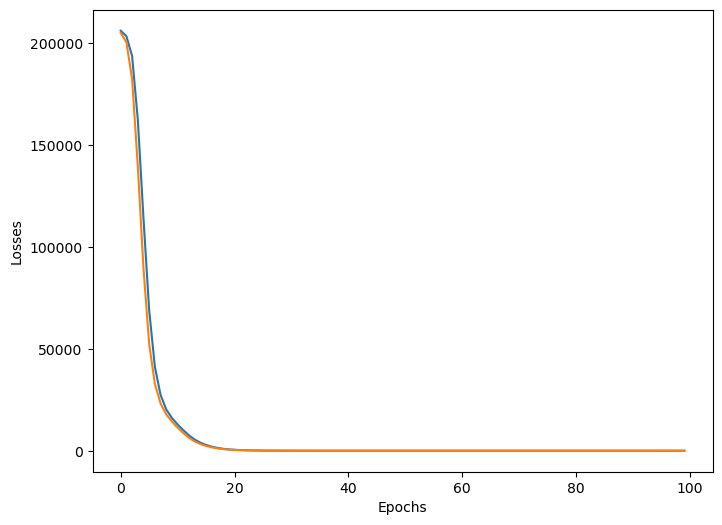

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(range(0,100),training_losses)
plt.plot(range(0,100),val_losses)

plt.xlabel("Epochs")
plt.ylabel("Losses")


### Picking the best model according to the validation set

In [26]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

### Evaluation

In [30]:
model.eval()
with torch.no_grad():
    Y_train_pred = model(X_train_tensor)
    Y_test_pred = model(X_test_tensor)

    train_mse_loss = criterion(Y_train_pred,Y_train_tensor)
    test_mse_loss = criterion(Y_test_pred,Y_test_tensor)

print(f"Training MSE: {train_mse_loss.item()} || Testing MSE: {test_mse_loss.item()}")

Training MSE: 20.57178497314453 || Testing MSE: 18.77599334716797


In [36]:
from sklearn.metrics import r2_score

print("Train R2 Score:",r2_score(Y_train_pred,Y_train_tensor))
print("Test R2 Score:",r2_score(Y_test_pred,Y_test_tensor))

Train R2 Score: 0.9251891189698047
Test R2 Score: 0.9304361056753911


In [44]:
predicted = pd.DataFrame(
    Y_test_pred.numpy(),columns=["Predicted Value"]
)

actual = pd.DataFrame(
    Y_test.values,columns=["Actual Values"]
)
pd.concat([predicted,actual],axis=1)
predicted["Error"] = abs(predicted["Predicted Value"] - actual["Actual Values"])/100


In [53]:
predicted[predicted["Error"]>0.15]

,Predicted Value,Error
174,467.920227,0.159902
486,468.655243,0.199652
720,474.330383,0.156896
1090,488.183044,0.283230
1146,477.786591,0.150934
1433,455.304749,0.266347
1465,478.774719,0.180547
